<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 9.1: NN with Keras
INSTRUCTIONS:
- Read the guides and hints, then create the necessary analysis and code to find an answer and conclusion for the task below.
- **NOTE**: This is a Regression problem. Consider the appropriate:
    - Activation function
    - Loss/Cost Function
    - Metrics

### Import libraries

In [1]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.0-cp313-cp313-win_amd64.whl.metadata (35 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
   -------------------------

In [18]:
# insert code here
## Import libraries
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input

import tensorflow as tf
from tensorflow import keras

print("Keras version: ", keras.__version__)
print("Tensorflow version: ", tf.__version__)

Keras version:  3.14.0
Tensorflow version:  2.21.0


### Load data
Load the Diabetes dataset from **SciKit-Learn**.

In [19]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

### Prepare input data

In [20]:
X = diabetes.data

# print the type of X to check that it is a numpy array
print("X is a ", type(X))

# Print shape to check rows and columns
print("X has {} rows and {} columns".format(X.shape[0], X.shape[1]))

# Save number of columns as n_cols
n_cols = X.shape[1]

# output
y = diabetes.target

print("First 10 values in y: ", y[:10])

X is a  <class 'numpy.ndarray'>
X has 442 rows and 10 columns
First 10 values in y:  [151.  75. 141. 206. 135.  97. 138.  63. 110. 310.]


### Split the data (training/test)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 65)

### Create the model's architecture

In [28]:
model = Sequential()

model.add(Input(shape=(X_train2.shape[1],))) 
model.add(Dense(12, activation='relu'))

# 3. Add an output layer 
# For regression (predicting a number), we use 1 unit with no activation or 'linear'
model.add(Dense(1))

In [29]:
X = diabetes.data

# print the type of X to check that it is a numpy array
print("X is a ", type(X))

# Print shape to check rows and columns
print("X has {} rows and {} columns".format(X.shape[0], X.shape[1]))

# Save number of columns as n_cols
n_cols = X.shape[1]

# output
y = diabetes.target

print("First 10 values in y: ", y[:10])

X is a  <class 'numpy.ndarray'>
X has 442 rows and 10 columns
First 10 values in y:  [151.  75. 141. 206. 135.  97. 138.  63. 110. 310.]


In [30]:
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

None


### Compile the model

In [31]:
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mse'])

### Fit the training data

In [32]:
%%time
# insert code here
# shuffle training data
from sklearn.utils import shuffle
X_train2, y_train2 = shuffle(X_train, y_train, random_state=42)

CPU times: total: 0 ns
Wall time: 516 μs


In [38]:
history = model.fit(
    X_train2,
    y_train2,
    validation_split = 0.25,
    batch_size = 10,
    epochs = 1000,
    verbose = 1)

Epoch 1/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14958.7344 - mse: 14958.7344 - val_loss: 14300.5752 - val_mse: 14300.5752
Epoch 2/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14712.2324 - mse: 14712.2314 - val_loss: 14059.9795 - val_mse: 14059.9805
Epoch 3/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14471.9932 - mse: 14471.9932 - val_loss: 13819.3730 - val_mse: 13819.3730
Epoch 4/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14238.8955 - mse: 14238.8955 - val_loss: 13597.6143 - val_mse: 13597.6143
Epoch 5/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14019.6025 - mse: 14019.6025 - val_loss: 13380.7529 - val_mse: 13380.7529
Epoch 6/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13802.6865 - mse: 13802.6875 - val_loss: 13165.6582 - val_mse: 13165.6582
Epoch 7/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13578.8984 - mse: 13578.8984 - val_loss: 12948.3057 - val_mse: 12948.3057
Epoch 8/1000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13

### Create predictions

In [39]:
predictions = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [40]:
print(predictions)

[[177.83943 ]
 [190.46571 ]
 [167.726   ]
 [234.40027 ]
 [191.32843 ]
 [263.76776 ]
 [155.33066 ]
 [ 66.60794 ]
 [151.72696 ]
 [172.11497 ]
 [219.98593 ]
 [195.58008 ]
 [ 95.08827 ]
 [227.9718  ]
 [ 92.78743 ]
 [222.32918 ]
 [ 82.35556 ]
 [124.65469 ]
 [135.37988 ]
 [157.47142 ]
 [ 82.29492 ]
 [ 80.56927 ]
 [194.45016 ]
 [122.624146]
 [229.3851  ]
 [189.30191 ]
 [119.52713 ]
 [ 94.459496]
 [183.78699 ]
 [229.46976 ]
 [229.12524 ]
 [233.49641 ]
 [161.92325 ]
 [119.47627 ]
 [127.78974 ]
 [158.62115 ]
 [108.170166]
 [231.30487 ]
 [206.85858 ]
 [127.52514 ]
 [100.266975]
 [123.32625 ]
 [185.93549 ]
 [230.24008 ]
 [142.62108 ]
 [262.4815  ]
 [155.94116 ]
 [199.14569 ]
 [164.09264 ]
 [145.0832  ]
 [136.83766 ]
 [210.49403 ]
 [170.47998 ]
 [150.6502  ]
 [201.71436 ]
 [ 71.73851 ]
 [169.11133 ]
 [113.8674  ]
 [163.64624 ]
 [ 82.812096]
 [146.62405 ]
 [148.28432 ]
 [201.82938 ]
 [244.11324 ]
 [181.13109 ]
 [168.72113 ]
 [112.445145]
 [201.80179 ]
 [212.00296 ]
 [103.22046 ]
 [175.65872 ]
 [170.

### Evaluate the model

In [41]:
score = model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3291.1440 - mse: 3291.1440 


### Visualization of cost

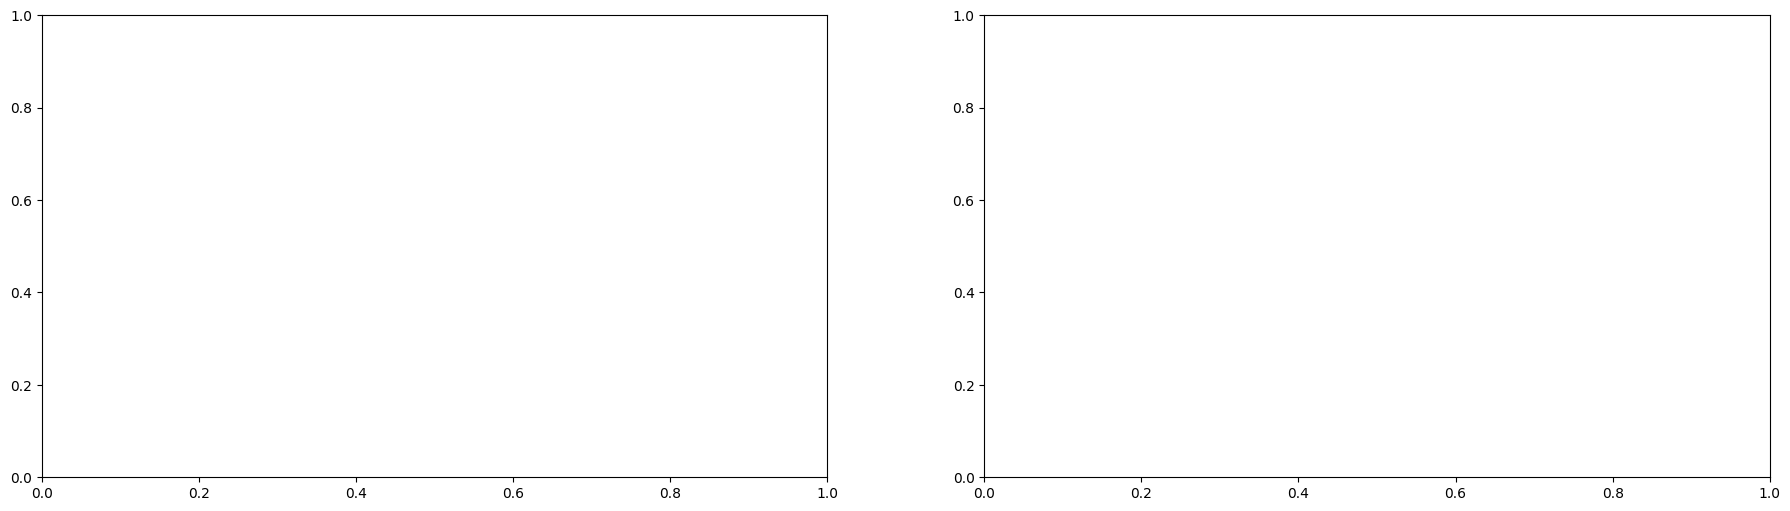

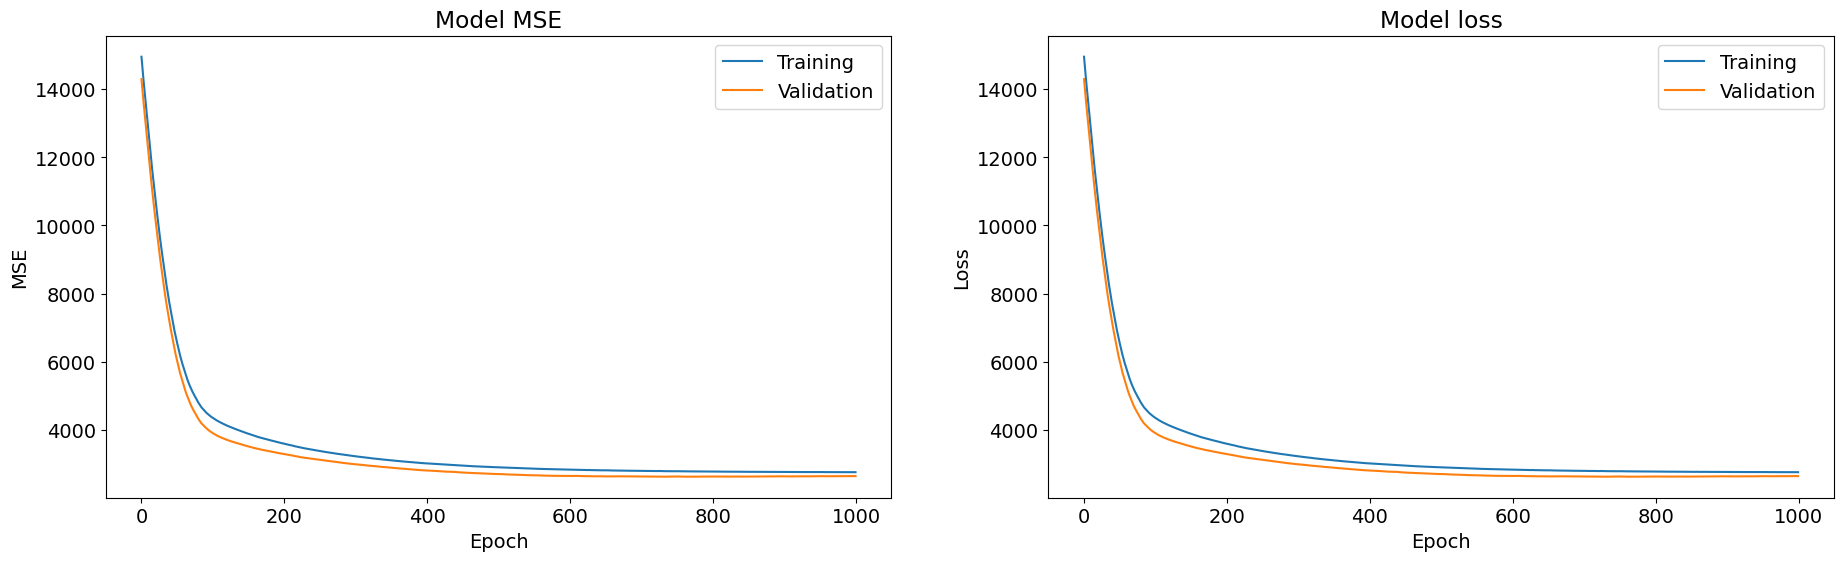

In [42]:
fig, ax = plt.subplots(1, 2, figsize = (18, 6))
fig.subplots_adjust(left = 0.02, right = 0.98, wspace = 0.2)

plt.rcParams.update({'font.size': 14})

# Plot training & validation accuracy values
ax[0].plot(history.history['mse'], label = 'Training')
ax[0].plot(history.history['val_mse'], label = 'Validation')
ax[0].set_title('Model MSE')
ax[0].set_ylabel('MSE')
ax[0].set_xlabel('Epoch')
ax[0].legend()

# Plot training & validation loss values
ax[1].plot(history.history['loss'], label = 'Training')
ax[1].plot(history.history['val_loss'], label = 'Validation')
ax[1].set_title('Model loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.show()

### Visualization of residuals

In [43]:
r2 = r2_score(y_test, predictions)
n, p = X.shape # sample size, number of explanatory variables
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

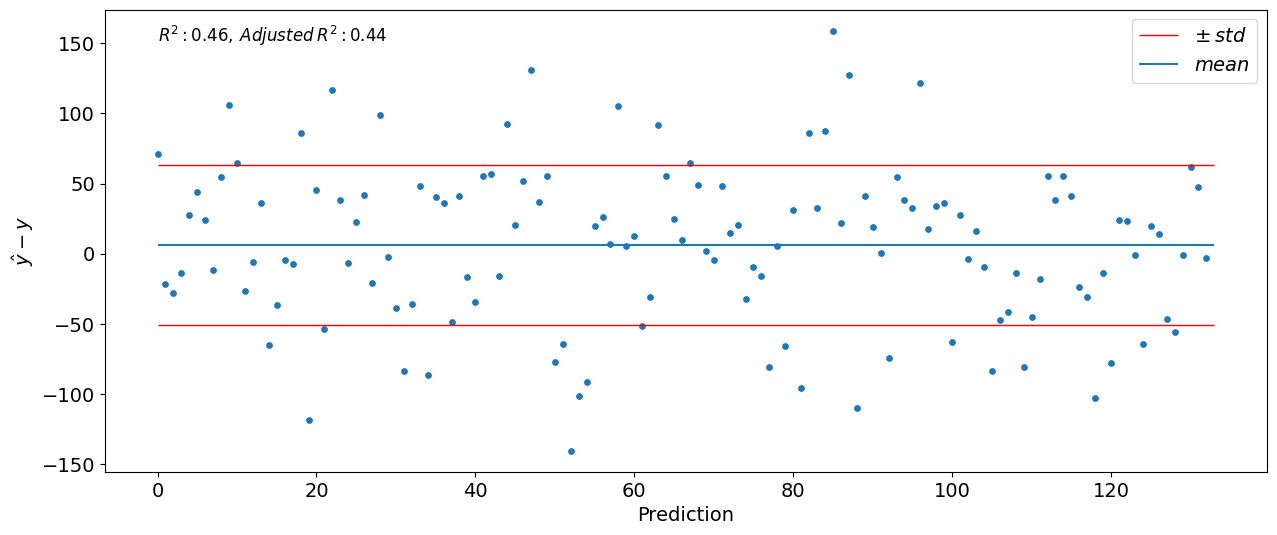

In [44]:
difference = predictions.flatten() - y_test
d_mean = difference.mean()
d_std = difference.std()
n_pred = len(predictions)
plt.figure(figsize = (15, 6))
plt.scatter(range(n_pred), difference, s = 15)
plt.hlines(d_mean + d_std, 0, n_pred, 'r', lw = 1, label = '$\pm \: std$')
plt.hlines(d_mean, 0, n_pred, label = '$mean$')
plt.hlines(d_mean - d_std, 0, n_pred, 'r', lw = 1)
plt.xlabel('Prediction')
plt.ylabel('$\hat y - y$')
plt.legend()
plt.text(0, difference.max() * 0.95,
         '$R^2: %.2f, \: Adjusted \: R^2: %.2f$' % (r2, adjusted_r2),
         fontsize = 12)
plt.show()



---



---



> > > > > > > > > © 2026 Institute of Data


---



---



